# Exploratory analysis / diagnostics

In [77]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
# read in data
reviews = gpd.read_file("data/neigh_reviews_subset.gpkg")
# drop existing neighborhood-level gentrification indicators
reviews = reviews.drop(columns="gentrified")
reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,index_right,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551)
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551)
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551)
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551)
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551)


In [47]:
# check the columns
reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry'],
      dtype='object')

## Subset to brewery reviews

In [78]:
# turn the strings in 'categories' to lowercase to make things easier
reviews['categories'] = reviews['categories'].str.lower()

# check out the unique values of reviews containing "brew"
reviews[reviews['categories'].str.contains("brew")]['categories'].unique()

array(['eatertainment, arts & entertainment, brewpubs, american (traditional), bakeries, breweries, food, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, restaurants, breweries, bars, nightlife',
       'breweries, brewpubs, food, hot dogs, restaurants, sandwiches',
       'american (new), bars, food, pubs, breweries, pizza, restaurants, nightlife',
       'food, breweries, restaurants',
       'brewpubs, food, restaurants, american (traditional), breweries',
       'american (traditional), nightlife, food, bars, restaurants, beer, wine & spirits, american (new), pubs, local flavor, breweries, event planning & services, venues & event spaces',
       'american (new), breweries, desserts, american (traditional), restaurants, food',
       'nightlife, breweries, bars, food, pubs, restaurants, brewpubs',
       'italian, brazilian, coffee & tea, breakfast & brunch, breweri

In [80]:
# check out the unique values of reviews containing "beer" --  particularly to see if non-brewery establishments contain "beer"
reviews[reviews['categories'].str.contains("beer")]['categories'].unique()

array(['nightlife, bars, beer, wine & spirits, pubs, irish, food, restaurants',
       'food, nightlife, restaurants, irish pub, bars, irish, pubs, beer, wine & spirits, event planning & services, gastropubs, caterers',
       'bars, food, restaurants, beer, wine & spirits, american (traditional), nightlife',
       'chicken wings, nightlife, bars, delis, food, beer gardens, sandwiches, beer bar, restaurants, beer, wine & spirits, gastropubs',
       'beer, wine & spirits, restaurants, specialty food, food, sandwiches, delis, fruits & veggies, grocery',
       'food, restaurants, nightlife, pizza, bars, beer, wine & spirits',
       'italian, food, nightlife, pizza, bars, cocktail bars, beer, wine & spirits, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, delis, beer, wine & spirits, restaurants',
       'restaurants, burgers, nightlife, beer, wine & spirits, american (

In [139]:
print(sum(reviews['categories'].str.contains("brewpubs")))
print(sum(reviews['categories'].str.contains("breweries")))
#print(sum(reviews['categories'].str.contains("beer"))) # we find including "beer" to be too general
print(sum(reviews['categories'].str.contains("beer bar")))
print(sum(reviews['categories'].str.contains("beer garden")))
print(sum(reviews['categories'].str.contains("brew house")))

2160
7729
16137
6121
0


In [124]:
reviews['brewery'] = np.where((reviews['categories'].str.contains("brewpubs")) | (reviews['categories'].str.contains("breweries")) | (reviews['categories'].str.contains("beer bar")) | (reviews['categories'].str.contains("beer garden")), 1, 0)

reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry,brewery
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551),0
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551),0
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551),0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551),0
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551),0


## Join with census tract gentrification indicators

In [84]:
tracts_gent = gpd.read_file("data/Philadelphia_Tracts_Gent.geojson")
tracts_gent.head() 

,FID,OBJECTID,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,LOGRECNO,SHAPE_AREA,SHAPE_LEN,GentYN,geometry
0,0,46,42,101,005000,42101005000,50,Census Tract 50,G5020,S,4504459,3340294,+39.8898768,-075.1691412,10389,8.832943e+07,48033.335048,0,"POLYGON ((-75.17215 39.88129, -75.16966 39.881..."
1,1,47,42,101,005400,42101005400,54,Census Tract 54,G5020,S,1846253,530013,+39.8904539,-075.2513923,10390,2.575213e+07,24624.823144,0,"POLYGON ((-75.24623 39.88951, -75.24585 39.889..."
2,2,48,42,101,005500,42101005500,55,Census Tract 55,G5020,S,1168442,12010,+39.9074191,-075.2489174,10391,1.270364e+07,20389.059940,0,"POLYGON ((-75.25129 39.90441, -75.25179 39.903..."
3,3,49,42,101,005600,42101005600,56,Census Tract 56,G5020,S,840411,0,+39.8988328,-075.2447347,10392,9.047139e+06,11788.147571,0,"POLYGON ((-75.24184 39.90384, -75.24196 39.903..."
4,4,50,42,101,006000,42101006000,60,Census Tract 60,G5020,S,1089657,0,+39.9115196,-075.2381570,10393,1.175557e+07,14205.267812,0,"POLYGON ((-75.23342 39.91385, -75.23369 39.914..."


In [85]:
tracts_gent.columns

Index(['FID', 'OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10',
       'NAME10', 'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'SHAPE_AREA', 'SHAPE_LEN',
       'GentYN', 'geometry'],
      dtype='object')

In [126]:

#reviews = reviews.drop(columns="index_right")
reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'review_id', 'user_id',
       'useful', 'funny', 'cool', 'text', 'date', 'geometry', 'brewery'],
      dtype='object')

In [127]:
# spatial join with reviews data
reviews_tracts = reviews.sjoin(tracts_gent[["GentYN", "TRACTCE10", "GEOID10", "geometry"]], how = "left",predicate= "intersects")
reviews_tracts.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,funny,cool,text,date,geometry,brewery,index_right,GentYN,TRACTCE10,GEOID10
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200


In [143]:
# reproject to EPSG:2272
reviews_tracts.crs = reviews_tracts.to_crs("EPSG:2272")

ValueError: The truth value of a GeoDataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
reviews_tracts.crs

In [128]:
reviews_tracts.shape[0]

682950

In [129]:
sum(reviews_tracts['brewery']==1)

28090

## Time series plots

In [130]:
reviews_tracts['date'] = pd.to_datetime(reviews_tracts['date'])
print(min(reviews_tracts.date))
print(max(reviews_tracts.date))

2005-02-16 04:06:26
2022-01-19 19:46:34


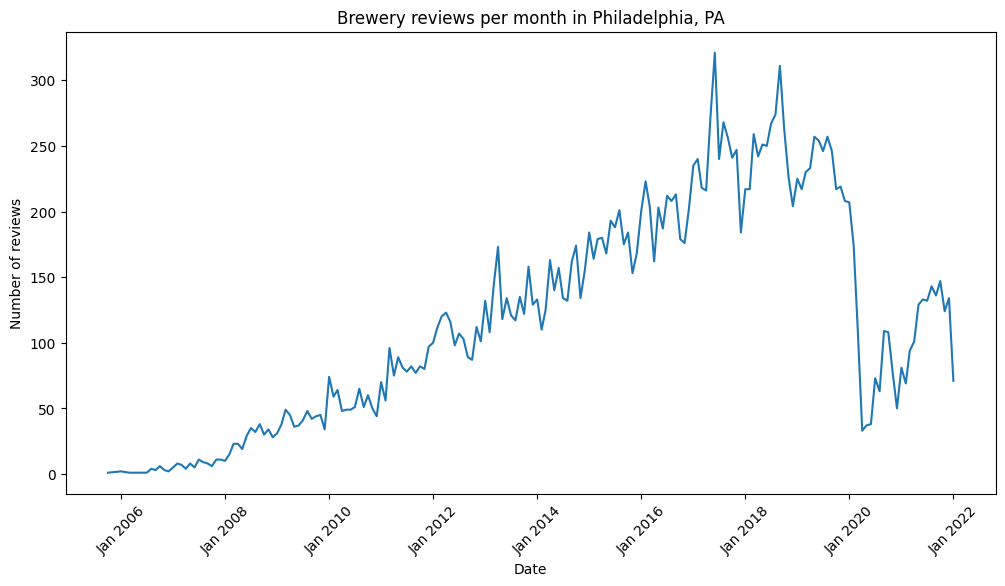

In [106]:
# plot number of brewery reviews across time
reviews_tracts['date'] = pd.to_datetime(reviews_tracts['date'])
breweries = reviews_tracts[reviews_tracts['brewery']== 1]


review_counts = breweries.groupby(breweries['date'].dt.to_period('M')).size().reset_index(name='n')
review_counts['date'] = review_counts['date'].dt.to_timestamp()
review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Philadelphia, PA")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

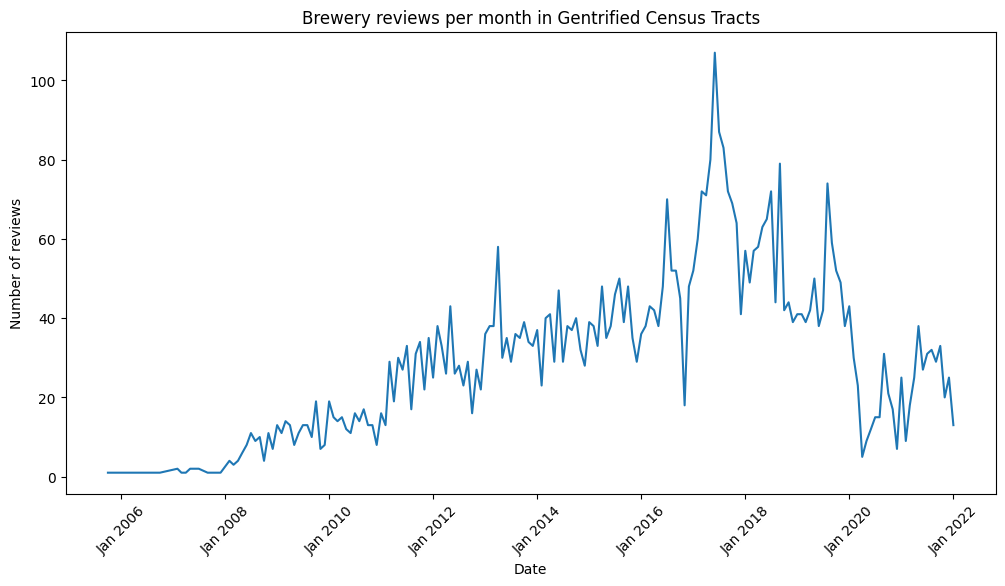

In [107]:
gentrified = breweries[breweries['GentYN'] == 1]

gent_review_counts = gentrified.groupby(gentrified['date'].dt.to_period('M')).size().reset_index(name='n')
gent_review_counts['date'] = gent_review_counts['date'].dt.to_timestamp()
gent_review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(gent_review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Gentrified Census Tracts")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

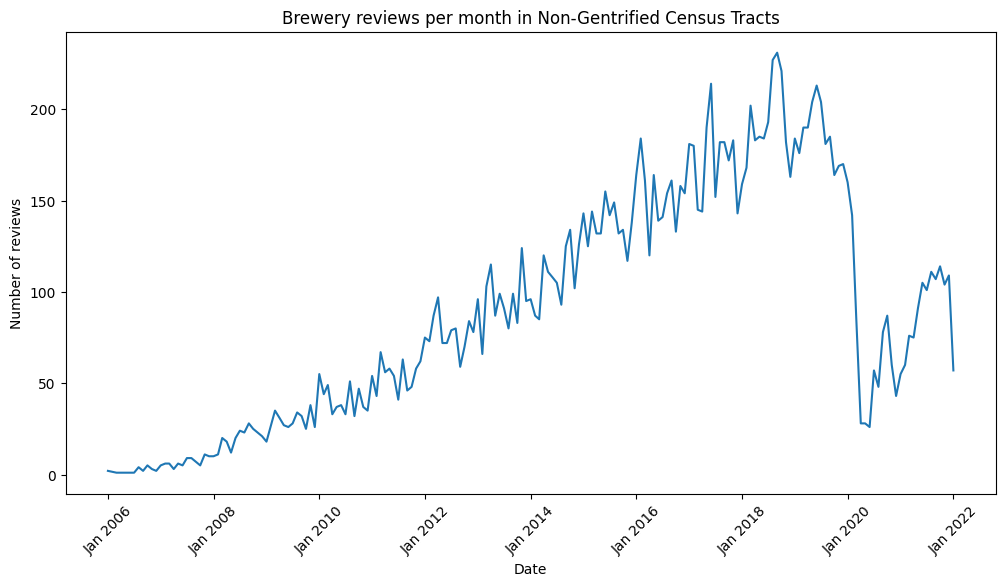

In [109]:
non_gentrified = breweries[breweries['GentYN'] == 0]

ng_review_counts = non_gentrified.groupby(non_gentrified['date'].dt.to_period('M')).size().reset_index(name='n')
ng_review_counts['date'] = ng_review_counts['date'].dt.to_timestamp()
ng_review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(ng_review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Non-Gentrified Census Tracts")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

## Restrict to pre-gentrification data time period (before 2010)

In [131]:
reviews_pre = reviews_tracts[reviews_tracts['date'] < '01-01-2010']
reviews_pre.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,funny,cool,text,date,geometry,brewery,index_right,GentYN,TRACTCE10,GEOID10
26,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,St Honore Pastries is another one of those pla...,2008-06-16 13:41:58,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
29,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,2.0,A nice Chinese bakery that gets you the goods....,2008-03-09 00:36:56,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
34,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,Arguably the best Chinese pastry shop in Phill...,2009-02-21 22:07:07,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
39,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,Stopped in yesterday while on an unsuccessful ...,2009-02-15 20:11:58,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200
49,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,One of the better places in Philadelphia China...,2009-01-27 14:42:24,POINT (-75.15556 39.95551),0,145.0,0.0,000200,42101000200


In [132]:
# check number of reviews in remaining data
reviews_pre.shape[0]

34610

In [133]:
sum(reviews_pre['brewery'] == 1)

927

## Join with census track race/ethnicity data

In [134]:
race = pd.read_csv("data/race_ethn_cleaned_2010.csv")
race.head()

,Unnamed: 0,geography,geographic_area_name,tot_pop,TRACTCE,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,0,1400000US42101000100,"Census Tract 1, Philadelphia County, Pennsylvania",3478,100.0,0.063830,0.125359,0.036228,0.774583
1,1,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937,200.0,0.102826,1.280899,0.026898,-0.410623
2,2,1400000US42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",3169,300.0,0.107920,0.244241,0.042600,0.605238
3,3,1400000US42101000401,"Census Tract 4.01, Philadelphia County, Pennsy...",2125,401.0,0.186353,0.525176,0.050353,0.238118
4,4,1400000US42101000402,"Census Tract 4.02, Philadelphia County, Pennsy...",3142,402.0,0.056652,0.243794,0.034691,0.664863


In [135]:
reviews_pre['TRACTCE10'] = reviews_pre['TRACTCE10'].astype(str).str.zfill(6)
reviews_pre = reviews_pre.rename(columns={"TRACTCE10": "TRACTCE"})
race['TRACTCE'] = race['TRACTCE'].dropna().astype(int).astype(str).str.zfill(6)
reviews_pre_demog = pd.merge(reviews_pre, race, how="left", on="TRACTCE")
reviews_pre_demog.head()

/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,TRACTCE,GEOID10,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,42101000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623


In [136]:
reviews_pre_demog.shape[0]

34610

In [141]:
reviews_pre_demog.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
reviews_pre_demog.to_file("data/pre_2010_reviews.gpkg")